# Figure 1A

In [10]:
import os
import tifffile
from imaris_ims_file_reader.ims import ims
import numpy as np
import napari
from cellpose import models
from cellpose.utils import stitch3D

# import utils from the parent directory
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.stitch_3d import stitch_3d 

# Load in example image to show slices
name = "ExpBSc2_TL_ITD1_20x_260513_F08"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
frame = 16
channel = 2 #crc channel
# image = ims(os.path.join(input_directory, f"{name}.ims"))[frame, channel] 
cropped = ims(os.path.join(input_directory, f"{name}_cropped.ims"))[frame, channel] 
print(cropped.shape)
# segmentation = tifffile.imread(os.path.join(input_directory, f"{name}_segmented.tif"))[frame, :]
# print(segmentation.shape)


# model = models.CellposeModel(
#         gpu=("cuda" == "cuda"), pretrained_model=r"C:\Users\6331823\Local SSD\20260511 CARE BSc\Train Low segmenter\models\low_input"
#     )
# model = models.CellposeModel(
#         gpu=("cuda" == "cuda"), pretrained_model=r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models\2d_high_quality_model"
#     )


# cp = []
# for z in range(cropped.shape[0]):
#     print(f"Running cellpose on z-slice {z}...")
#     masks, _, _ = model.eval(cropped[z],
#                 diameter=None,
#                 normalize=True,
#                 flow_threshold=0.4,
#                 invert=False,
#                 resample=True,
#                 do_3D=False,
#                 progress=None,
#                 )
#     cp.append(masks)
# cp = np.stack(cp, axis=0)
# cp = stitch3D(cp)
# tifffile.imwrite(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"), cp.astype(np.uint16))

cp = tifffile.imread(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"))
print(f"Cellpose seg cell numbers: {len(np.unique(cp))}")
nuclogic = stitch_3d(cp, cropped, breaking_threshold = 0.3)
# nuclogic2 = stitch_3d(nuclogic, cropped)

# Show in napari
contrast = (np.median(cropped) * 1.2, np.percentile(cropped, 99.98))
scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)
viewer.dims.ndisplay = 3
y_half = slice(0, cropped.shape[1] // 2)
x_half = slice(0, cropped.shape[2])
print(y_half, x_half)
viewer.add_image(cropped[:, y_half, x_half], contrast_limits=contrast, scale=scale)
viewer.add_labels(cp[:, y_half, x_half], scale=scale, iso_gradient_mode="smooth", visible=False)
viewer.add_labels(nuclogic[:, y_half, x_half], scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_labels(cp, scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_labels(nuclogic2, scale=scale, iso_gradient_mode="smooth", visible=False)

# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle

Opening readonly file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

(63, 294, 290)
Cellpose seg cell numbers: 310
Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 2095 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 311 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 58 breaks.
    Iteration 2: Made 22 breaks.
    Iteration 3: Made 16 breaks.
    Iteration 4: Made 3 breaks.
Finding touching cell pairs...
Found 347 pairs of touching cells.
Splitted 70 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 10 small cells, and removed 15 cells without suitable neighbors.
Final stitched mask has 385 cells.
slice(0, 147, None) slice(0, 290, None

Figure 2

In [1]:
# Figure 2A

import os
import tifffile
from imaris_ims_file_reader.ims import ims
import numpy as np
import napari
import scipy.ndimage

# import utils from the parent directory
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.stitch_3d import stitch_3d 
from utils.expand_mask import expand_mask_3d

# Load in example image to show slices
name = "ExpBSc2_TL_ITD1_20x_260513_F08"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
frame = 16
channel = 2 #crc channel
# image = ims(os.path.join(input_directory, f"{name}.ims"))[frame, channel] 
cropped = ims(os.path.join(input_directory, f"{name}_cropped.ims"))[frame, channel] 
print(cropped.shape)

# cp = []
# for z in range(cropped.shape[0]):
#     print(f"Running cellpose on z-slice {z}...")
#     masks, _, _ = model.eval(cropped[z],
#                 diameter=None,
#                 normalize=True,
#                 flow_threshold=0.4,
#                 invert=False,
#                 resample=True,
#                 do_3D=False,
#                 progress=None,
#                 )
#     cp.append(masks)
# cp = np.stack(cp, axis=0)
# cp = stitch3D(cp)
# tifffile.imwrite(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"), cp.astype(np.uint16))

cp = tifffile.imread(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"))
print(f"Cellpose seg cell numbers: {len(np.unique(cp))}")
nuclogic = stitch_3d(cp, cropped, breaking_threshold = 2)
# nuclogic2 = stitch_3d(nuclogic, cropped)

# Show in napari
contrast = (np.median(cropped) * 1.2, np.percentile(cropped, 99.98))
scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)
viewer.dims.ndisplay = 3
y_half = slice(0, cropped.shape[1] // 2)
x_half = slice(0, cropped.shape[2])
print(y_half, x_half)

selected_mask_cp = cp == 167  # show only the mask for cell 174
selected_mask_cp = np.where(selected_mask_cp, cp, 0)  # create a masked image where only the selected cell is visible
# cropped_masked = expand_mask_3d(selected_mask_cp, dilation_size_um = 2, voxel_size=scale)  # dilate the mask to make it more visible
# cropped_masked = np.where(cropped_masked, cropped, 0)  # create a masked image where only the selected cell is visible
selected_ids_nuclogic = [166, 336]
selected_mask_nuclogic = np.isin(nuclogic, selected_ids_nuclogic)  # create mask where the selected cells are visible
selected_mask_nuclogic = np.where(selected_mask_nuclogic, nuclogic, 0)  # create a masked image where only the selected cells are visible
# target_z = np.where(selected_mask_nuclogic)[0].min() + 5
# nuclogic_display = nuclogic.copy()
# # replace both cell IDs only in that single slice
# nuclogic_display[target_z][np.isin(nuclogic_display[target_z], [166, 336])] = 166


# viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_image(cropped_masked, contrast_limits=(contrast[0], contrast[1]/1.7), scale=scale, colormap="Greys")
viewer.add_labels(selected_mask_cp, scale=scale, colormap={0: "", 167: "magenta"}, iso_gradient_mode="smooth", visible=True, opacity=1)
# viewer.add_labels(nuclogic_display, scale=scale, colormap={0: "", 166: "magenta", 336: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)
# viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False)

# # Reset view to the data bounds, then set a side-view camera angle (XZ view)
# viewer.reset_view()
# viewer.camera.center = (83.24123779650657, 96.3297331771258, 59.20690029145916)
# viewer.camera.angles = (180, 0.6526549938471702, 0.413991687612314)
# viewer.camera.zoom = 12.308777811410637
# @viewer.bind_key('c')  # press 'c' to capture camera state
# def print_camera(viewer):
#     print(f"viewer.camera.center = {viewer.camera.center}")
#     print(f"viewer.camera.angles = {viewer.camera.angles}")
#     print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# # make scale bar visible
# viewer.scale_bar.visible = True
# viewer.scale_bar.unit = 'µm'
# #toggle grid mode on
# viewer.grid.enabled = True
# viewer.theme = 'light'

# # save screenshot
# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
# napari.run()
# # viewer.screenshot(path=os.path.join(output_directory, "2A.png"), canvas_only=True, scale = 2)

Opening readonly file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

(63, 294, 290)
Cellpose seg cell numbers: 310
Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 2095 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 311 cells formed.
Starting iterative breaking of cells
Cell 166 break scores:
  Volume break scores: [0, 0.9032813846033362, 0.7951773315819103, 1.2251157407407407, 1.1290666666666669, 0.8769322235434006, 1.387234809242827, 0.8830795748348177, 0.8891657766702267, 0.8779217558435117, 0]
  Intensity break scores: [0, 0.8492980268904382, 0.91223470190151, 0.8789276647534391, 0.9990466362153788, 1.387835958498404, 1.022743029860302, 0.9343847063029113, 1.046150241330675, 1.

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\standardize_color.py:91: UserWarning: Empty string detected. Returning black instead.
  warnings.warn(


<Labels layer 'selected_mask_cp' at 0x1d900553a90>

In [2]:
# print the most bottom nonzero slice of the selected mask to check if the bottom part of the cell is still visible
print("Most bottom nonzero slice of the selected mask:")
print(np.where(selected_mask_nuclogic)[0].min())

Most bottom nonzero slice of the selected mask:
28


In [ ]:
# Figure 2A_bottom
# Show in napari

scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)


# viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_image(cropped_masked, contrast_limits=(contrast[0], contrast[1]/1.7), scale=scale, colormap="Greys")
viewer.add_labels(selected_mask_cp, scale=scale, colormap={0: "", 167: "magenta"}, iso_gradient_mode="smooth", visible=True, opacity=1)
viewer.add_labels(nuclogic_display, scale=scale, colormap={0: "", 166: "magenta", 336: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)


# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewer.camera.center = (81.7789406621335, 22.667029017368154, 88.64139740486563)
viewer.camera.angles = (178.06352653830456, -84.03938801581167, 2.1125919814583987)
viewer.camera.zoom = 12.308777811410637
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
# viewer.screenshot(path=os.path.join(output_directory, "2A_bottom.png"), canvas_only=True, scale = 3)

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


In [2]:
# Figure 2b final
# Show in napari

scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)

selected_ids_nuclogic = [166, 343]
selected_mask_nuclogic = np.isin(nuclogic, selected_ids_nuclogic)  # create mask where the selected cells are visible
# selected_mask_nuclogic = np.where(selected_mask_nuclogic, nuclogic, 0)  # create a masked image where only the selected cells are visible

viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False)
nuclogic2 = stitch_3d(nuclogic, cropped, breaking_threshold = 2)
viewer.add_labels(nuclogic2, scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_labels(selected_mask_nuclogic, scale=scale, colormap={0: "", 166: "magenta", 343: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)


# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewer.camera.center = (81.7789406621335, 22.667029017368154, 88.64139740486563)
viewer.camera.angles = (178.06352653830456, -84.03938801581167, 2.1125919814583987)
viewer.camera.zoom = 12.308777811410637
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
viewer.screenshot(path=os.path.join(output_directory, "2B_final.png"), canvas_only=True, scale = 3)

Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 2213 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 364 cells formed.
Starting iterative breaking of cells
Cell 166 break scores:
  Volume break scores: [0, 2.3714285714285714, 0.8465608465608466, 0.8779213238496153, 0.9096137152777779, 1.0520833333333335, 0.8469757866875796, 0.8603703703703703, 0]
  Intensity break scores: [0, 0.9282447968593451, 1.0870938958260137, 1.217307202571666, 0.996838532179134, 0.8590281509355322, 0.9518647819844411, 1.1132058805582201, 0]
  Line break scores (up): [0.         0.         1.15613345 3.80633368 2.32554158 0.21497982
 0.41075812 0.19655939 0.0941902 ]
  Line distances (up): [0.57806672 1.15613345 0.57806672 3.80633368 4.70905905 5.3968046
 6.49530828 7.79037133 9.17962459]
  Line break scores (down): [0.         1.16928662 1.79121567 0.94175093 0.13594289 

array([[[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       ...,

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255

In [10]:
# Figure synthetic data
# Code to create synthetic data for testing the stitching algorithm
from skimage.draw import ellipsoid
import napari
import os
from scipy.ndimage import zoom, gaussian_filter
import numpy as np

def make_cell(radius_Z, radius_Y, radius_X, intensity=255):
    """Create a binary ellipsoidal cell"""
    cell = ellipsoid(radius_Z, radius_Y, radius_X)
    cell = cell.astype(np.uint16) * intensity
    return cell


def paste_cell(volume, mask, cell, position, label):
    cz, cy, cx = position.astype(int)
    dz, dy, dx = cell.shape
    hz, hy, hx = dz // 2, dy // 2, dx // 2

    z0, z1 = max(0, cz - hz), min(volume.shape[0], cz + hz + 1)
    y0, y1 = max(0, cy - hy), min(volume.shape[1], cy + hy + 1)
    x0, x1 = max(0, cx - hx), min(volume.shape[2], cx + hx + 1)

    cell_z0 = hz - (cz - z0)
    cell_y0 = hy - (cy - y0)
    cell_x0 = hx - (cx - x0)

    subcell = cell[
        cell_z0 : cell_z0 + (z1 - z0),
        cell_y0 : cell_y0 + (y1 - y0),
        cell_x0 : cell_x0 + (x1 - x0),
    ]

    if subcell.size == 0:
        return False

    volume[z0:z1, y0:y1, x0:x1] = np.maximum(volume[z0:z1, y0:y1, x0:x1], subcell)
    mask[z0:z1, y0:y1, x0:x1][subcell > 0] = label
    return True

from scipy.ndimage import affine_transform


def _rotation_matrix(from_vec, to_vec):
    a = from_vec / (np.linalg.norm(from_vec) + 1e-8)
    b = to_vec / (np.linalg.norm(to_vec) + 1e-8)
    v = np.cross(a, b)
    c = np.dot(a, b)
    if np.isclose(c, 1.0):
        return np.eye(3)
    if np.isclose(c, -1.0):
        # 180° flip around any perpendicular axis
        perp = np.array([1.0, 0.0, 0.0])
        if np.allclose(a, perp):
            perp = np.array([0.0, 1.0, 0.0])
        v = perp - a * np.dot(perp, a)
        v /= np.linalg.norm(v)
        vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
        return np.eye(3) + 2 * vx @ vx
    vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
    return np.eye(3) + vx + vx @ vx * ((1 - c) / (np.linalg.norm(v) ** 2 + 1e-8))


def orient_cell(cell, direction_vec):
    base = np.array([1.0, 0.0, 0.0])  # +z axis in (z, y, x) ordering
    pad = int(max(cell.shape) * 0.75)
    padded = np.pad(
        cell,
        ((pad, pad), (pad, pad), (pad, pad)),
        mode="constant",
        constant_values=0,
    )
    R = _rotation_matrix(base, direction_vec)
    center = (np.array(padded.shape) - 1) / 2
    matrix = R.T
    offset = center - matrix @ center
    rotated = affine_transform(
        padded,
        matrix=matrix,
        offset=offset,
        order=1,
        mode="constant",
        cval=0,
    )
    return rotated.astype(cell.dtype)


def can_place(mask, cell, position):
    cz, cy, cx = position.astype(int)
    dz, dy, dx = cell.shape
    hz, hy, hx = dz // 2, dy // 2, dx // 2

    z0, z1 = max(0, cz - hz), min(mask.shape[0], cz + hz + 1)
    y0, y1 = max(0, cy - hy), min(mask.shape[1], cy + hy + 1)
    x0, x1 = max(0, cx - hx), min(mask.shape[2], cx + hx + 1)

    if z0 >= z1 or y0 >= y1 or x0 >= x1:
        return False

    cell_z0 = hz - (cz - z0)
    cell_y0 = hy - (cy - y0)
    cell_x0 = hx - (cx - x0)

    subcell = cell[
        cell_z0 : cell_z0 + (z1 - z0),
        cell_y0 : cell_y0 + (y1 - y0),
        cell_x0 : cell_x0 + (x1 - x0),
    ]

    return np.all(mask[z0:z1, y0:y1, x0:x1][subcell > 0] == 0)

def generate_synthetic_organoid(number_of_cells = 250, max_attempts = 30, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (300,300,300), organoid_size = 250):
    volume = np.zeros(vol_shape, dtype=np.uint16)
    mask = np.zeros_like(volume)

    center = np.array(vol_shape) // 2

    for cell_idx in range(number_of_cells):
        # create a binomial distrubution around the radii with the arms reaching the randomness value
        rand_radius_X = int(radius_X + np.random.uniform(-randomness, randomness) * radius_X)
        rand_radius_Y = int(radius_Y + np.random.uniform(-randomness, randomness) * radius_Y)
        rand_radius_Z = int(radius_Z + np.random.uniform(-randomness, randomness) * radius_Z)
        cell = make_cell(rand_radius_Z, rand_radius_Y, rand_radius_X, intensity=255)

        placed = False
        for attempt in range(max_attempts):
            # get a random position at distance of organoid_size/2 from center
            u = np.random.uniform(-1, 1)  # cos(theta)
            phi = np.random.uniform(0, 2 * np.pi)
            theta = np.arccos(u)
            r = organoid_size / 2 # controls how far from center the cells are placed
            pos_z = int(center[0] + r * u)
            sin_theta = np.sqrt(1 - u * u)
            pos_y = int(center[1] + r * sin_theta * np.cos(phi))
            pos_x = int(center[2] + r * sin_theta * np.sin(phi))
            position = np.array([pos_z, pos_y, pos_x])

            # place the cell in the volume at the random position
            direction = center - position  # point toward organoid center
            oriented_cell = orient_cell(cell, direction)

            if not can_place(mask, oriented_cell, position):
                continue

            paste_success = paste_cell(volume, mask, oriented_cell, position, label=cell_idx + 1)
            if paste_success:
                placed = True
                print(
                    f"Cell {cell_idx+1}: position=({pos_z}, {pos_y}, {pos_x}), radii=({rand_radius_Z}, {rand_radius_Y}, {rand_radius_X})"
                )
                break

    if not placed:
        print(f"Cell {cell_idx}: skipped after {max_attempts} attempts")

    return volume, mask

seed = 1
np.random.seed(seed)
rng = np.random.default_rng(seed)

def generate_synthetic_data(number_of_cells = 250, max_attempts = 30, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (300,300,300), organoid_size = 250):

    synthetic_ogranoid, synthetic_mask = generate_synthetic_organoid(number_of_cells = 200, max_attempts = 30, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (300,300,300), organoid_size = 250)
    rescale = ((synthetic_ogranoid.shape[0] / (2.5 / 0.64) / synthetic_ogranoid.shape[0]), 1.0, 1.0)
    synthetic_ogranoid = zoom(synthetic_ogranoid, zoom=rescale, order=1)
    mask = zoom(synthetic_mask, zoom=rescale, order=0)
    output_directory = r"C:\Users\6331823\Local SSD\Fake_data"

    unique_labels = np.unique(mask)
    unique_labels = unique_labels[unique_labels > 0]

    brightness_volume = np.zeros_like(synthetic_ogranoid, dtype=np.float32)

    for lbl in unique_labels:
        cell_voxels = mask == lbl
        cell_mean = np.clip(rng.normal(150, 30), 50, 300)
        cell_noise = rng.normal(loc=cell_mean, scale=5, size=cell_voxels.sum())
        lo = max(150, cell_mean - 10)
        hi = min(250, cell_mean + 10)
        brightness_volume[cell_voxels] = np.clip(cell_noise, lo, hi)

    brightness_volume = brightness_volume.astype(np.uint16)


    # # create noise and PSF
    # gaussian_volume = gaussian_filter(
    #     brightness_volume.astype(np.float32), sigma=(1.6, 0.6, 0.6)
    # )
    # treat the per-cell brightness as photon counts (so Poisson SNR is meaningful)
    signal_photons = brightness_volume.astype(np.float32)

    # --- PSF (optics) : anisotropic, effective = diffraction floor + tissue scatter ---
    em, NA, n = 0.680, 1.0, 1.33                 # 638 ex -> ~680 em far-red, water immersion
    vox = np.array([2.5, 0.64, 0.64])            # (z, y, x) um after the zoom
    fwhm = np.array([1.4 * n * em / NA**2, 0.51 * em / NA, 0.51 * em / NA])
    sigma_diffraction = fwhm / 2.355 / vox       # ~sub-voxel at this sampling
    sigma_eff = np.maximum(sigma_diffraction, [2, 0.7, 0.7])   # your values, as scatter floor
    blurred = np.empty_like(signal_photons)
    nz = signal_photons.shape[0]
    for z in range(nz):
        depth_frac = np.sqrt(z / nz)                      # 0 = bottom (near objective), 1 = deep
        sz = 1.2 + 1.6 * depth_frac              # axial blur grows with depth
        sxy = 0.5 + 0.5 * depth_frac             # lateral blur grows with depth
        # blur a small Z-window around slice z so axial smear is captured
        z0, z1 = max(0, z-4), min(nz, z+5)
        blurred[z] = gaussian_filter(signal_photons[z0:z1], sigma=(sz, sxy, sxy))[z-z0]

    # --- depth-dependent signal loss (absorption/scattering deeper in the organoid) ---
    depth = np.linspace(0.0, 1.0, blurred.shape[0], dtype=np.float32)   # 0 = top, 1 = deepest
    top, bottom = 0.9, 0.02
    z_profile = (top - (top - bottom) * depth**0.3)[:, None, None]
    photons = blurred * z_profile + 3.0          # + small autofluorescence/stray-light background

    # --- NOISE at the detector (this is the part the Gaussian was missing) ---
    detected = rng.poisson(photons).astype(np.float32)   # shot noise (signal-dependent)
    detected += rng.normal(0, 1.5, detected.shape)       # sCMOS read noise ~1-2 e-
    realistic_volume = np.clip(detected + 100.0, 0, 65535).astype(np.uint16)  # +camera offset

    return realistic_volume, mask

# print(realistic_volume.sum())
# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
# tifffile.imwrite(os.path.join(output_directory, "synthetic_organoid.tif"), realistic_volume)
# tifffile.imwrite(os.path.join(output_directory, "synthetic_organoid_gt.tif"), mask.astype(np.uint16))

In [56]:
z_profile

array([[[0.9       ]],

       [[0.6599848 ]],

       [[0.60450673]],

       [[0.5662856 ]],

       [[0.5362051 ]],

       [[0.5110179 ]],

       [[0.48914936]],

       [[0.4697033 ]],

       [[0.45211595]],

       [[0.43600708]],

       [[0.42110687]],

       [[0.40721625]],

       [[0.39418352]],

       [[0.38189042]],

       [[0.3702426 ]],

       [[0.35916352]],

       [[0.34859008]],

       [[0.33846956]],

       [[0.3287577 ]],

       [[0.31941652]],

       [[0.31041342]],

       [[0.30172014]],

       [[0.293312  ]],

       [[0.28516734]],

       [[0.27726686]],

       [[0.2695936 ]],

       [[0.2621323 ]],

       [[0.25486928]],

       [[0.24779218]],

       [[0.24088985]],

       [[0.2341522 ]],

       [[0.22756994]],

       [[0.22113472]],

       [[0.21483874]],

       [[0.20867497]],

       [[0.20263684]],

       [[0.19671828]],

       [[0.19091362]],

       [[0.18521786]],

       [[0.17962605]],

       [[0.17413372]],

       [[0.16873

In [18]:
import numpy as np
from skimage.measure import regionprops

def centroid_accuracy(gt, pred_mask):
    gt = np.asarray(gt)
    pred_mask = np.asarray(pred_mask)
    if gt.shape != pred_mask.shape:
        raise ValueError("Masks must share shape")

    gt_props = regionprops(gt)
    hit_pred_labels = set()
    predicted_labels = np.array([])
    tp = fn = merged_cells = 0

    for prop in gt_props:
        centroid = np.rint(prop.centroid).astype(int)
        centroid = tuple(np.clip(centroid, 0, np.array(gt.shape) - 1))
        pred_label = pred_mask[centroid]
        predicted_labels = np.append(predicted_labels, pred_label)
        if pred_label > 0:
            if pred_label in hit_pred_labels:
                # This predicted label has already been matched to a ground truth cell
                fn += 1
                merged_cells += 1
            else:
                tp += 1
                hit_pred_labels.add(int(pred_label))
        else:
            fn += 1

    pred_labels = set(np.unique(pred_mask))
    pred_labels.discard(0)
    fp = len(pred_labels - hit_pred_labels)
    fp_list = list(pred_labels - hit_pred_labels)

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if precision + recall else 0.0

    gt_binary = gt > 0
    pred_binary = pred_mask > 0
    intersection = np.count_nonzero(gt_binary & pred_binary)
    dice = (
        (2 * intersection) / (gt_binary.sum() + pred_binary.sum())
        if (gt_binary.sum() + pred_binary.sum())
        else 0.0
    )

    return {
        "true_positives": tp,
        "false_negatives": fn,
        "false_positives": fp,
        "merged_cells": merged_cells,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "voxel_dice": dice,
        "false_positive_labels": fp_list,
    }

# print(centroid_accuracy(gt, pred_mask))
# print(f"actual amount of cells: {len(np.unique(gt)) - 1}, predicted amount of cells: {len(np.unique(pred_mask)) - 1}")

In [21]:
from pathlib import Path
import os
import sys
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
from utils.stitch_3d import stitch_3d
import importlib
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.load_model import load_model
from utils.stitch_3d import stitch_3d
from cellpose import models
from time import time
import tifffile


output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

mask = tifffile.imread(os.path.join(output_directory, "synthetic_organoid_gt.tif"))
realistic_volume = tifffile.imread(os.path.join(output_directory, "synthetic_organoid.tif"))
# model = load_model(r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models\2d_low_quality_model")
# time0 = time()
# segmented_2d = segment(realistic_volume, model)
# tifffile.imwrite(os.path.join(output_directory, "synthetic_segmented_2d.tif"), segmented_2d.astype(np.uint16))
segmented_2d = tifffile.imread(os.path.join(output_directory, "synthetic_segmented_2d.tif"))
nuclogic = stitch_3d(segmented_2d, realistic_volume, breaking_threshold = 4)
# time1 = time()
# cp4,_,_ = model.eval(
#                 realistic_volume,
#                 diameter=None,
#                 normalize=True,
#                 flow3D_smooth=0.0,
#                 invert=False,
#                 resample=True,
#                 do_3D=True,
#                 z_axis=0
#             )
# tifffile.imwrite(os.path.join(output_directory, "synthetic_segmented_cp4.tif"), cp4.astype(np.uint16))
# time2 = time()
cp4 = tifffile.imread(os.path.join(output_directory, "synthetic_segmented_cp4.tif"))
np.set_printoptions(suppress=True, precision=4)
print(f"Real mask {len(np.unique(mask))},NucLogic {len(np.unique(nuclogic))}, Cellpose 4 {len(np.unique(cp4))}")
# print(f"NucLogic time: {time1-time0:.2f}s, Cellpose 4 time: {time2-time1:.2f}s")
nuclogic2 = stitch_3d(nuclogic, realistic_volume, breaking_threshold = 4)
centroid_acc_nuclogic = centroid_accuracy(mask, nuclogic)
centroid_acc_cp4 = centroid_accuracy(mask, cp4)
centroid_acc_nuclogic2 = centroid_accuracy(mask, nuclogic2)
print(f"NucLogic centroid accuracy: {centroid_acc_nuclogic}")
print(f"NucLogic 2 centroid accuracy: {centroid_acc_nuclogic2}")
print(f"Cellpose 4 centroid accuracy: {centroid_acc_cp4}")


Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 1847 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 162 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 25 breaks.
Cell 171 break scores:
  Number of slices: 10
  Volume break scores: [0.    0.    0.    0.    0.375 1.515 0.375 0.    0.    0.   ]
  Intensity break scores: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Line break scores (up): [0.     0.     0.1872 0.6663 0.2444 0.6353 0.6851 0.938  0.4727 0.6803]
  Line break scores (down): [0.     0.4944 0.2553 0.1928 0.5123 0.6913 0.9267 0.9328 0.2975 0.    ]
  IOU break scores: [0, 0.10576923076923073, 0.034653465346534684, 0.0, 0.05022831050228316, 0.07981220657277, 0.10426540284360186, 0.11822660098522164, 0.19148936170212771, 0, 0, 0.10576923076923073, 0.034653465346534684, 0.0, 0.05022831050228316, 0.07981220657277, 0.10426540284

Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 1847 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 162 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 153 breaks.
Cell 171 break scores:
  Number of slices: 9
  Volume break scores: [0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Intensity break scores: [0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Line break scores (up): [0.     0.     0.1198 0.2073 0.0709 0.2658 0.7136 0.9809 1.4613]
  Line break scores (down): [0.     0.3543 0.0697 0.0137 0.2517 0.7117 1.4123 0.3707 0.    ]
  IOU break scores: [0, 0.06986899563318782, 0.0, 0.033542976939203384, 0.03578947368421048, 0.04008438818565396, 0.0, 0.21287128712871284, 0, 0, 0.06986899563318782, 0.0, 0.033542976939203384, 0.03578947368421048, 0.04008438818565396, 0.0, 0.21287128712871284, 0, 0, 0.06986899563318782, 0.0, 0.033542976939203384, 0.035789473684

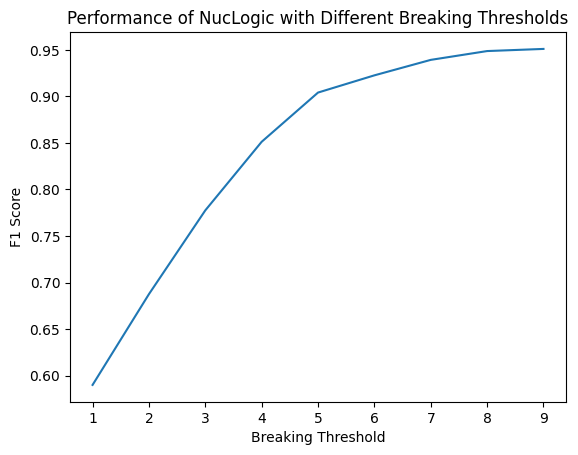

In [111]:
f1_values = []
for breaking_threshold in np.arange(1,10,1):
    nuclogic = stitch_3d(segmented_2d, realistic_volume, breaking_threshold = breaking_threshold)
    f1 = centroid_accuracy(mask, nuclogic)["f1"]
    f1_values.append(f1)

plt.plot(np.arange(1,10,1), f1_values)
plt.xlabel("Breaking Threshold")
plt.ylabel("F1 Score")
plt.title("Performance of NucLogic with Different Breaking Thresholds")
plt.show()

In [22]:
import napari

viewer = napari.Viewer(ndisplay=3)
viewer.grid.enabled = True
scale = (2.5, 0.64, 0.64)
viewer.add_image(realistic_volume, scale = scale)
viewer.add_labels(mask, scale = scale, iso_gradient_mode="smooth")
viewer.add_labels(nuclogic, scale = scale, iso_gradient_mode="smooth")
viewer.add_labels(cp4, scale = scale, iso_gradient_mode="smooth")

<Labels layer 'cp4' at 0x127a6a9bbd0>

In [11]:
# generate 20 fake organoids and segment them
from pathlib import Path
import os
import sys
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
from utils.load_model import load_model
import tifffile


model = load_model(r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models\2d_low_quality_model")

gt_masks = []
segmented_masks = []
realistic_datasets = []

for i in range(20):
    np.random.seed(i)
    rng = np.random.default_rng(i)

    realistic_volume, mask = generate_synthetic_data(number_of_cells = 200, max_attempts = 30, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (300,300,300), organoid_size = 250)
    gt_masks.append(mask)
    realistic_datasets.append(realistic_volume)

    segmented_2d = segment(realistic_volume, model)
    segmented_masks.append(segmented_2d)
    
    

Using CUDA for processing.
loaded custom model: 2d_low_quality_model
Cell 1: position=(161, 39, 207), radii=(5, 13, 12)
Cell 2: position=(265, 115, 181), radii=(5, 11, 12)
Cell 3: position=(256, 209, 178), radii=(5, 12, 13)
Cell 4: position=(219, 221, 74), radii=(5, 9, 10)
Cell 5: position=(220, 226, 220), radii=(4, 13, 14)
Cell 6: position=(91, 166, 41), radii=(5, 10, 12)
Cell 7: position=(179, 57, 71), radii=(4, 12, 11)
Cell 8: position=(114, 39, 196), radii=(5, 14, 12)
Cell 9: position=(192, 178, 263), radii=(5, 9, 12)
Cell 10: position=(272, 171, 166), radii=(4, 11, 10)
Cell 11: position=(88, 43, 172), radii=(5, 10, 10)
Cell 12: position=(189, 226, 240), radii=(4, 10, 10)
Cell 13: position=(49, 188, 86), radii=(5, 11, 10)
Cell 14: position=(269, 120, 126), radii=(4, 14, 10)
Cell 15: position=(55, 126, 227), radii=(4, 9, 13)
Cell 16: position=(41, 128, 92), radii=(4, 11, 10)
Cell 17: position=(48, 85, 116), radii=(5, 10, 12)
Cell 18: position=(57, 132, 67), radii=(5, 11, 14)
Cell 19

## Learn the break-score formula with PySR
Builds a per-slice training table from the channel scores + ground-truth mask, then runs symbolic regression to get a human-readable formula.

In [12]:
# =============================================================================
# Build the per-slice training table for PySR
# -----------------------------------------------------------------------------
# Goal: instead of hand-tuning the weights in get_break_scores(), let PySR LEARN
# a human-readable formula that maps the 5 per-slice channel scores
#       [v, i, up, down, iou]   ->   "is this slice a real break?"
#
# How the training data is made (NO full-pipeline runs, so it's fast):
#   * features = the exact per-channel scores get_break_scores() already computes
#   * labels   = read off the ground-truth mask: a slice is a TRUE break when the
#                dominant GT nucleus changes between the slice below and above it
#                (i.e. two stacked nuclei meet there).
#
# NOTE: this fits a per-slice PROXY, not end-to-end F1 directly. Use it to FIND
#       the formula's shape; polish the constants vs real F1 later if you want.
# =============================================================================

import numpy as np
from scipy.ndimage import binary_dilation
import sys
import os
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))

from utils.stitch_3d import (
    get_2d_mask_properties, IOU_stitching,
    get_volume_break_scores, get_intensity_break_scores,
    get_line_break_scores, get_IOU_break_scores,
    get_centroid_positions,
)

# ---- 1. Datasets: (cellpose_2d_mask, intensity_image, ground_truth_mask) -----
# Add more (seg, image, gt) triples as you annotate more organoids. More
# organoids -> more break examples -> a more trustworthy formula.
datasets = list(zip(segmented_masks, realistic_datasets, gt_masks))

EDGE = 3          # break_stitching forces the first/last 3 slices to score 0,
                  # so we never train on them (the model is never used there).
MIN_SLICES = 7    # break_stitching also ignores cells shorter than 7 slices.


def dominant_gt_per_slice(cell, gt_mask):
    """Most common ground-truth label among a cell's voxels, one value per slice.

    0 means 'background / no GT here'. At this pipeline stage coords_set_2d holds
    FLAT (y*W + x) indices, so we unflatten them with the stored 2D width before
    indexing the GT volume.
    """
    z_dim = gt_mask.shape[0]
    width = cell.shape_2d[1]
    doms = []
    for si, centroid in enumerate(cell.centroids_2d):
        z = min(max(int(round(centroid[0])), 0), z_dim - 1)
        coords = cell.coords_set_2d[si]
        if not coords:
            doms.append(0)
            continue
        ys, xs = np.divmod(np.fromiter(coords, dtype=np.int64), width)
        labels = gt_mask[z, ys, xs]
        labels = labels[labels > 0]                      # ignore background voxels
        doms.append(int(np.bincount(labels).argmax()) if labels.size else 0)
    return doms


def features_and_labels_for_cell(cell, gt_mask):
    """Build (list of feature rows, list of 0/1 labels) for one over-merged cell."""
    n = len(cell.volumes_2d)
    if n < MIN_SLICES:
        return [], []

    # --- the 5 channels, computed EXACTLY like get_break_scores() does ---
    v_scores = np.asarray(get_volume_break_scores(cell), dtype=float)
    i_scores = np.asarray(get_intensity_break_scores(cell), dtype=float)

    z_pos, y_pos, x_pos = get_centroid_positions(cell.centroids_2d)
    up, _   = get_line_break_scores(z_pos, y_pos, x_pos)
    up      = np.concatenate([[0], up[:-1]])             # same shift/padding as the pipeline
    down, _ = get_line_break_scores(z_pos[::-1], y_pos[::-1], x_pos[::-1])
    down    = down[::-1]                                 # un-reverse to slice order
    iou     = np.asarray(get_IOU_break_scores(cell), dtype=float)

    # --- labels from ground truth: dominant GT nucleus changing == a break ---
    dom = dominant_gt_per_slice(cell, gt_mask)

    # "core" break: dominant GT nucleus changes between slice k-1 and k
    core = np.zeros(n, dtype=bool)
    for k in range(1, n):
        if dom[k] > 0 and dom[k - 1] > 0 and dom[k] != dom[k - 1]:
            core[k] = True

    # spread each break onto its +/-1 neighbours (the break's true slice is
    # uncertain to about a slice either way)
    break_mask = binary_dilation(core, iterations=1)

    X_rows, y_rows = [], []
    for k in range(EDGE, n - EDGE):                      # skip the forced-zero edges
        X_rows.append([v_scores[k], i_scores[k], up[k], down[k], iou[k]])
        y_rows.append(1.0 if break_mask[k] else 0.0)
    return X_rows, y_rows


# ---- 2. Assemble the training table over all datasets ------------------------
X_all, y_all = [], []
for seg, img, gt in datasets:
    # Rebuild the over-merged organoid (the first two steps of stitch_3d, i.e.
    # BEFORE any breaking) so each cell may still contain several stacked nuclei.
    organoid = get_2d_mask_properties(seg, img)
    organoid = IOU_stitching(organoid, distance_threshold=10, iou_threshold=0.3)
    for cell in organoid:
        Xr, yr = features_and_labels_for_cell(cell, gt)
        X_all.extend(Xr)
        y_all.extend(yr)

X = np.array(X_all, dtype=float)
y = np.array(y_all, dtype=float)
print(f"Training rows: {len(y)}  |  true breaks: {int(y.sum())} "
      f"({100 * y.mean():.1f}% positive)")

# Break slices are RARE, so weight them up; otherwise the formula just learns to
# 'never break'. Balanced weights make one positive worth as much as one negative.
n_pos = max(y.sum(), 1)
weights = np.where(y > 0, (len(y) - y.sum()) / n_pos, 1.0)


Creating unique mask for properties calculation...
Unique mask created with 1781 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 157 cells formed.
Creating unique mask for properties calculation...
Unique mask created with 1847 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 162 cells formed.
Creating unique mask for properties calculation...
Unique mask created with 1784 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 167 cells formed.
Creating unique mask for properties calculation...
Unique mask created with 1811 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 164 cells formed.
Creating unique mask for properties calculation...
Unique mask created with 1786

In [13]:
# =============================================================================
# Fit PySR to discover an interpretable break-score formula
# Run the cell above first (it builds X, y, weights).
# =============================================================================
import pandas as pd
from pysr import PySRRegressor

# Wrap X in a named DataFrame so PySR prints v/i/up/down/iou instead of x0..x4.
X_df = pd.DataFrame(X, columns=["v", "i", "up", "down", "iou"])

model = PySRRegressor(
    niterations=100,                    # more iterations = better search, slower
    maxsize=20,                         # cap formula size -> stays human-readable
    binary_operators=["+", "*", "-", "max", "min"],   # add "min"/"max" here for AND/OR gating.
    unary_operators=["square", "sqrt"],
    elementwise_loss="L2DistLoss()",    # regress toward the 0/1 break label
    model_selection="best",             # auto-pick a good accuracy/simplicity point
    progress=True,
    # older PySR versions: rename 'elementwise_loss' to 'loss'
)

# weights up-weights the rare break slices (computed in the previous cell)
model.fit(X_df, y, weights=weights)     # DataFrame -> named variables in the output

# Pareto front: simplest -> most accurate formulas. Pick a short one you trust.
print(model)

# The single formula PySR rates best, as a readable sympy expression:
print("Best formula:")
print(model.sympy())

# =============================================================================
# How to use the result
# -----------------------------------------------------------------------------
# 1. Copy the printed formula (in terms of v, i, up, down, iou) into the
#    final_score block of get_break_scores() in utils/stitch_3d.py.
# 2. model.predict(X_df) gives a continuous break score; sweep breaking_threshold
#    (as in the F1-vs-threshold cell) to pick the cut.
# 3. Optional: re-tune just the numeric constants against true F1 with Optuna,
#    since PySR optimized the per-slice proxy, not the end-to-end metric.
# =============================================================================


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\pysr\sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
[ Info: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (`options.batching`), and also if you need that many datapoints. Unless you have a large amount of noise (in w


Expressions evaluated per second: 2.820e+04
Progress: 165 / 3100 total iterations (5.323%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.500e-01  0.000e+00  y = 0.49998
2           2.230e-01  1.143e-01  y = sqrt(iou)
3           2.062e-01  7.835e-02  y = iou + 0.32636
5           1.954e-01  2.676e-02  y = min(0.24969, iou) * 3.3982
6           1.940e-01  7.473e-03  y = max(0.29136, sqrt(iou * 1.7133))
7           1.841e-01  5.241e-02  y = max(min(0.84678, iou * 3.3594), 0.24666)
9           1.836e-01  1.195e-03  y = max(min(0.84678, iou * 3.3594), 0.24666) - i
12          1.824e-01  2.239e-03  y = min(max(0.23733, (sqrt(i) + (iou + iou)) + iou), 0.868...
                                      74)
14          1.812e-01  3.365e-03  y = min(max(0.23712, (sqrt(i) + iou) + (iou + io

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                         0.49998328   
	1   >>>>  0.114300                                          sqrt(iou)   
	2         0.078354                                   iou + 0.32635912   
	3         0.009448                          square(iou - -0.51817393)   
	4         0.044083                    min(iou * 3.3955202, 0.8488449)   
	5         0.007472             max(0.29138792, sqrt(iou) * 1.3088703)   
	6         0.053034   max(min(0.8477039, iou * 3.4400191), 0.23794067)   
	7         0.008688  min(0.84823805, max(min(0.32609954, up), iou *...   
	8         0.014569  square(min(0.91083694, max(min(0.639829, up), ...   
	9         0.002509  max(min(up, 0.5519698), min(0.2221983, iou) * ...   
	10        0.007965  max(min(1.0069642, up) * 0.45402312, min(0.829...   
	11        0.002366  max(min(0.85135424, iou * 3.3726132), min(0.56...   
	12      

## Optimize the combination against end-to-end F1 (Optuna)
Injects a parametrized `combine_fn` into `stitch_3d` and searches weights + threshold to maximize real F1, with a held-out validation split.

In [15]:
# =============================================================================
# Optimize the break combination against END-TO-END F1, scored ONLY on the hard
# (touching) cells. Isolated cells are easy and just dilute the signal, so we
# restrict recall to GT cells that touch another GT cell -- while STILL counting
# spurious splits inside that region as false positives (so the optimizer can't
# over-break for free).
#   %pip install optuna
# =============================================================================
import io, contextlib, importlib, copy
import numpy as np
import optuna
from scipy.ndimage import binary_dilation
import sys
import os
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))

# stitch_3d.py was edited to accept combine_fn -> reload so this session sees it.
import utils.stitch_3d
importlib.reload(utils.stitch_3d)
from utils.stitch_3d import (
    get_2d_mask_properties, IOU_stitching, get_break_scores,
    break_stitching, split_organoid_cells, stitch_small_cells, mask_from_organoid,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

# datasets = list(zip(segmented_masks, realistic_datasets, gt_masks))  # build cell


# ---- Define the "hard" set: GT cells the segmenter MERGES ---------------------
# The clean GT nuclei don't touch (gaps between them); merging is created by the
# PSF + segmentation. So we find hard cells from the IOU-stitched mask BEFORE
# breaking: GT nuclei that ended up inside the SAME stitched cell are exactly the
# ones the break formula must separate. This is weight-independent (breaking
# hasn't run yet) and fixed, so it's a valid evaluation set across trials.
def hard_gt_from_organoid(organoid, gt, min_overlap=10):
    """GT labels that share an IOU-stitched cell with another GT label."""
    z_dim = gt.shape[0]
    hard = set()
    for cell in organoid:
        width = cell.shape_2d[1]
        hits = []
        for si, centroid in enumerate(cell.centroids_2d):
            coords = cell.coords_set_2d[si]
            if not coords:
                continue
            z = min(max(int(round(centroid[0])), 0), z_dim - 1)
            ys, xs = np.divmod(np.fromiter(coords, dtype=np.int64), width)
            labs = gt[z, ys, xs]
            hits.append(labs[labs > 0])
        if not hits:
            continue
        # GT labels this stitched cell overlaps by at least min_overlap voxels
        u, counts = np.unique(np.concatenate(hits), return_counts=True)
        significant = u[counts >= min_overlap]
        if len(significant) >= 2:           # two+ GT nuclei merged into one cell
            hard.update(significant.tolist())
    return hard


def stitch_from_prebuilt(org0, shape, breaking_threshold, combine_fn):
    """Replicate stitch_3d's tail (break -> split -> small-cell merge -> mask) on
    a DEEP COPY of the cached pre-break organoid. The expensive, weight-independent
    prefix (2D properties + IOU stitching) is done ONCE, not per trial."""
    organoid = copy.deepcopy(org0)
    max_iterations, iteration, checked = 10, 0, set()
    while iteration < max_iterations:
        organoid = get_break_scores(organoid, skip_labels=checked, combine_fn=combine_fn)
        checked = {c.label for c in organoid}
        organoid, breaks_made, broken = break_stitching(
            organoid, breaking_threshold=breaking_threshold)
        checked -= broken
        if breaks_made == 0:
            break
        iteration += 1
    organoid = split_organoid_cells(organoid)
    organoid = stitch_small_cells(organoid)
    return mask_from_organoid(organoid, shape=shape)


def _centroids_int(label_img):
    """Vectorized integer centroids per label. Returns (labels, centroids)."""
    coords = np.nonzero(label_img)
    labs = label_img[coords]
    if labs.size == 0:
        return np.array([], dtype=int), np.zeros((0, label_img.ndim), dtype=int)
    nlab = int(labs.max()) + 1
    counts = np.bincount(labs, minlength=nlab)
    sums = np.stack(
        [np.bincount(labs, weights=c.astype(float), minlength=nlab) for c in coords],
        axis=1,
    )
    valid = np.nonzero(counts)[0]
    valid = valid[valid > 0]
    cent = np.rint(sums[valid] / counts[valid][:, None]).astype(int)
    cent = np.clip(cent, 0, np.array(label_img.shape) - 1)
    return valid, cent


def centroid_accuracy_hard(gt, pred, hard_labels, hard_region):
    """F1 over the hard GT cells only; FP counted for spurious predicted cells
    whose centroid falls inside the hard region (so over-breaking is penalized)."""
    gt_hard = np.where(np.isin(gt, hard_labels), gt, 0)

    # recall side: match each hard GT centroid to a predicted label
    _, gt_cent = _centroids_int(gt_hard)
    pred_at = pred[tuple(gt_cent.T)] if len(gt_cent) else np.array([], dtype=int)
    pos = pred_at > 0
    hit = np.unique(pred_at[pos])
    tp = hit.size
    merged = int(pos.sum()) - tp                 # extra GT cells sharing a pred label
    fn = int((~pos).sum()) + merged

    # precision side: predicted cells inside the hard region that match no hard GT
    pred_labels, pred_cent = _centroids_int(pred)
    if len(pred_labels):
        inside = hard_region[tuple(pred_cent.T)]
        hit_set = set(hit.tolist())
        fp = int(sum(1 for lbl, ins in zip(pred_labels, inside)
                     if ins and lbl not in hit_set))
    else:
        fp = 0

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"f1": f1, "precision": precision, "recall": recall, "tp": tp, "fn": fn, "fp": fp}


# ---- Precompute the hard set per organoid (GT is fixed -> compute ONCE) -------
prebuilt, shapes = [], []
hard_labels_list, hard_regions = [], []
for seg, img, gt in datasets:
    # Build the pre-break organoid ONCE -> reused for the hard set AND every trial.
    with contextlib.redirect_stdout(io.StringIO()):
        org = get_2d_mask_properties(seg, img)
        org = IOU_stitching(org, distance_threshold=10, iou_threshold=0.3)
    prebuilt.append(org)
    shapes.append(seg.shape)

    hl = hard_gt_from_organoid(org, gt)
    hard_labels_list.append(np.array(sorted(hl), dtype=gt.dtype))
    hard_regions.append(binary_dilation(np.isin(gt, list(hl)), iterations=2))
print(f"Avg hard (merged) cells/organoid: "
      f"{np.mean([len(h) for h in hard_labels_list]):.0f}")


# ---- Train/val split over organoids ------------------------------------------
rng = np.random.default_rng(0)
order = rng.permutation(len(datasets))
train_idx = order[: len(datasets) * 2 // 3]      # ~2/3 train
val_idx   = order[len(train_idx):]
print(f"{len(train_idx)} train organoids, {len(val_idx)} val organoids")


def _f1_one(j, combine_fn, threshold):
    """HARD-cell F1 for a single organoid (run in a worker process)."""
    if len(hard_labels_list[j]) == 0:
        return None                               # no merged cells -> nothing to score
    gt = datasets[j][2]
    with contextlib.redirect_stdout(io.StringIO()):
        pred = stitch_from_prebuilt(prebuilt[j], shapes[j], threshold, combine_fn)
    return centroid_accuracy_hard(
        gt, pred, hard_labels_list[j], hard_regions[j])["f1"]


def mean_f1(combine_fn, threshold, idxs):
    """Mean HARD-cell F1 over the given organoids (serial; each reuses its cached
    pre-break organoid, so only the break tail is recomputed)."""
    f1s = [r for r in (_f1_one(j, combine_fn, threshold) for j in idxs) if r is not None]
    return float(np.mean(f1s)) if f1s else 0.0


def make_combine_fn(p):
    """Parametrized combination. Each interaction has its OWN weight, so this
    family is a strict superset of the baseline (line*v and line*i are weighted
    independently, not tied together)."""
    def fn(v, i, up, down, iou):
        line = max(up, down)
        return (p["w_i"]    * i
                + p["w_iou"]  * iou
                + p["w_liou"] * line * iou     # line x iou
                + p["w_vi"]   * v * i
                + p["w_lvi"] * line * v * i          # line x volume x iou  
                )         # volume x intensity
    return fn

PARAMS = ["w_i", "w_iou", "w_liou", "w_vi", "w_lvi"]

# ---- Baseline: current formula (combine_fn=None), best threshold -------------
# baseline_results = []
# for thr in np.arange(1, 10, 1):
#     f1 = mean_f1(None, thr, val_idx)
#     print(f"  baseline threshold {thr}: hard F1 = {f1:.3f}", flush=True)
#     baseline_results.append((f1, thr))
# baseline_f1, baseline_thr = max(baseline_results)
print(f"Baseline (current formula) HARD val F1: {baseline_f1:.3f} at threshold {baseline_thr}")


# ---- Optuna: threshold fixed at 1, weights carry the scale -------------------
FIXED_THRESHOLD = 4

def objective(trial):
    p = {k: trial.suggest_float(k, 0.0, 30.0, step=0.1) for k in PARAMS}  # 1 decimal; use step=0.01 for 2
    return mean_f1(make_combine_fn(p), FIXED_THRESHOLD, train_idx)

def log_cb(study, trial):
    """Print each trial's F1 and the running best (set verbosity=WARNING above)."""
    if trial.value is not None:
        print(f"trial {trial.number:3d}  F1={trial.value:.3f}  best={study.best_value:.3f} \n weights: { {k: round(v, 3) for k, v in trial.params.items()} }",
              flush=True)
SEED_WEIGHTS = {"w_i": 10.4, "w_iou": 14.0,
                "w_liou": 0.0, "w_vi": 20.0, "w_lvi": 1.0}
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.CmaEsSampler(x0=SEED_WEIGHTS, sigma0=0.1, seed=0),   # continuous weights -> CMA-ES
)
# Seed the baseline formula (rescaled to threshold=1) so trial 0 already scores
# ~baseline and the search can only improve from there.
study.enqueue_trial(SEED_WEIGHTS)
study.optimize(objective, n_trials=50, callbacks=[log_cb], show_progress_bar=True)

best = dict(study.best_params)
fn = make_combine_fn(best)
print("\nBest weights:", {k: round(v, 3) for k, v in best.items()})
print(f"Train HARD F1: {study.best_value:.3f}")
print(f"Val   HARD F1: {mean_f1(fn, FIXED_THRESHOLD, val_idx):.3f}   (baseline {baseline_f1:.3f})")


Avg hard (merged) cells/organoid: 68
13 train organoids, 7 val organoids
Baseline (current formula) HARD val F1: 0.909 at threshold 3


  0%|          | 0/50 [00:00<?, ?it/s]

trial   0  F1=0.967  best=0.967 
 weights: {'w_i': 10.4, 'w_iou': 14.0, 'w_liou': 0.0, 'w_vi': 20.0, 'w_lvi': 1.0}


Best trial: 0. Best value: 0.967451:   2%|▏         | 1/50 [00:07<06:02,  7.41s/it]

trial   1  F1=0.951  best=0.967 
 weights: {'w_i': 9.7, 'w_iou': 19.3, 'w_liou': 0.2, 'w_vi': 11.8, 'w_lvi': 0.0}


...

Best trial: 0. Best value: 0.967451:  98%|█████████▊| 49/50 [06:02<00:07,  7.38s/it]

trial  49  F1=0.964  best=0.967 
 weights: {'w_i': 15.2, 'w_iou': 13.0, 'w_liou': 0.8, 'w_vi': 18.7, 'w_lvi': 3.4}


Best trial: 0. Best value: 0.967451: 100%|██████████| 50/50 [06:09<00:00,  7.40s/it]


Best weights: {'w_i': 10.4, 'w_iou': 14.0, 'w_liou': 0.0, 'w_vi': 20.0, 'w_lvi': 1.0}
Train HARD F1: 0.967


Val   HARD F1: 0.965   (baseline 0.909)


Best weights: {'w_line': 0.0, 'w_v': 0.0, 'w_i': 10.0, 'w_iou': 10.0, 'w_lv': 0.0, 'w_li': 0.0, 'w_liou': 2.9, 'w_vi': 0.0}
Train HARD F1: 0.966


In [1]:
output_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
import tifffile
import os
# count = 0
# for seg, img, gt in datasets:
#     count += 1
#     tifffile.imwrite(os.path.join(output_directory, f"synthetic_organoid_{count}_segmented_2d.tif"), 
#                      seg.astype(np.uint16),
#                      compression="zlib",
#                      compressionargs={"level": 6})
#     tifffile.imwrite(os.path.join(output_directory, f"synthetic_organoid_{count}_img.tif"), 
#                      img.astype(np.uint16),
#                      compression="zlib",
#                      compressionargs={"level": 6})
#     tifffile.imwrite(os.path.join(output_directory, f"synthetic_organoid_{count}_gt.tif"), 
#                      gt.astype(np.uint16),
#                      compression="zlib",
                    #  compressionargs={"level": 6})

segs = []
imgs = []
gts = []
for i in range(1,21):
    seg = tifffile.imread(os.path.join(output_directory, f"synthetic_organoid_{i}_segmented_2d.tif"))
    segs.append(seg)
    img = tifffile.imread(os.path.join(output_directory, f"synthetic_organoid_{i}_img.tif"))
    imgs.append(img)
    gt = tifffile.imread(os.path.join(output_directory, f"synthetic_organoid_{i}_gt.tif"))
    gts.append(gt)
datasets = list(zip(segs, imgs, gts))
